In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("../dataset/correct_full.csv")

In [3]:
data.head(10)

,Дата,Группа,№ Группы,№ Объявления,Тип площадки,Формат,Размер изображения,Тип устройства,Пол,Категория таргетинга,...,Клики,CTR (%),wCTR (%),Расход (руб.),Конверсия (%)/Товар добавлен в корзину,Конверсия (%)/Заказ оформлен,Конверсия (%)/Лид с Centra Market//Динамика,Конверсии/Товар добавлен в корзину,Конверсии/Заказ оформлен,Конверсии/Лид с Centra Market//Динамика
0,15.06.2023,Велосипед Stinger,4296804875,M-9591380676,поиск,текстовый,без изображения,мобильные,не определен,Целевые запросы,...,0,0.0,0.00,0.00,-,-,-,-,-,-
1,15.06.2023,Велосипед Stinger,4296804875,M-9591380678,поиск,графический,с изображением,десктоп,мужской,Запросы с упоминанием конкурентов,...,0,0.0,0.00,0.00,-,-,-,-,-,-
2,15.06.2023,Велосипед Женский,4296804877,M-9591380694,поиск,графический,с изображением,десктоп,женский,Целевые запросы,...,0,0.0,0.00,0.00,-,-,-,-,-,-
3,15.06.2023,Велосипед Женский,4296804877,M-9591380696,поиск,графический,с изображением,десктоп,женский,Целевые запросы,...,0,0.0,0.00,0.00,-,-,-,-,-,-
4,15.06.2023,Велосипед Складной,4296804880,M-9591380710,поиск,текстовый,без изображения,мобильные,мужской,Целевые запросы,...,0,0.0,0.00,0.00,-,-,-,-,-,-
5,15.06.2023,Велосипед Детский,4296804882,M-9591380722,поиск,текстовый,без изображения,мобильные,женский,Целевые запросы,...,1,100.0,150.17,26.02,-,-,-,-,-,-
6,15.06.2023,Велосипед Детский,4296804882,M-9591380722,поиск,текстовый,без изображения,мобильные,женский,Целевые запросы,...,0,0.0,0.00,0.00,-,-,-,-,-,-
7,15.06.2023,Велосипед Детский,4296804882,M-9591380722,поиск,текстовый,без изображения,мобильные,женский,Целевые запросы,...,1,100.0,146.31,18.21,-,-,-,-,-,-
8,15.06.2023,Велосипед Детский,4296804882,M-9591380724,поиск,графический,с изображением,десктоп,мужской,Целевые запросы,...,1,100.0,97.10,41.47,-,-,-,-,-,-
9,15.06.2023,Велосипед Детский,4296804882,M-9591380724,поиск,графический,с изображением,десктоп,женский,Целевые запросы,...,1,100.0,138.12,15.49,-,-,-,-,-,-


In [4]:
import numpy as np

# Заменяем странные значения на NaN
strange_values = ["-", "—", "None", "nan", "NaN", ""]
df_new_processed = data.replace(strange_values, np.nan)

# Убираем колонки с пропусками и константные колонки
df_cleaned = df_new_processed.dropna(axis=1)

df_cleaned = df_cleaned.loc[:, (df_cleaned != df_cleaned.iloc[0]).any()]


numerical_cols_processed = df_cleaned.select_dtypes(include=['number']).columns.tolist()
categorical_cols_processed = df_cleaned.select_dtypes(exclude=['number']).columns.tolist()


In [5]:
from sklearn.preprocessing import OneHotEncoder

# Преобразуем категориальные признаки в числовые с помощью One-Hot Encoding
categorical_cols = categorical_cols_processed[1:]

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_array = encoder.fit_transform(df_new_processed[categorical_cols])

encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols))

# Combine with numerical columns (excluding target 'Показы')
X = encoded_df
# Показы , Расход (руб.)
y = df_new_processed["Расход (руб.)"]

X.shape, y.shape


((9923, 239), (9923,))

### Бинаризируем целевые значения - будем строить модель предсказания будут ли расходы выше нуля

In [9]:
y_bin = np.zeros_like(y)
y_bin[y>0] = 1
y_bin[y==0] = 0

### Строим базовую модель классификации

In [13]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)


svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)


y_pred = svm_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели SVM: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred))

Точность модели SVM: 86.85%
              precision    recall  f1-score   support

         0.0       0.87      1.00      0.93      1724
         1.0       0.00      0.00      0.00       261

    accuracy                           0.87      1985
   macro avg       0.43      0.50      0.46      1985
weighted avg       0.75      0.87      0.81      1985



/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Пробуем снизить размерность

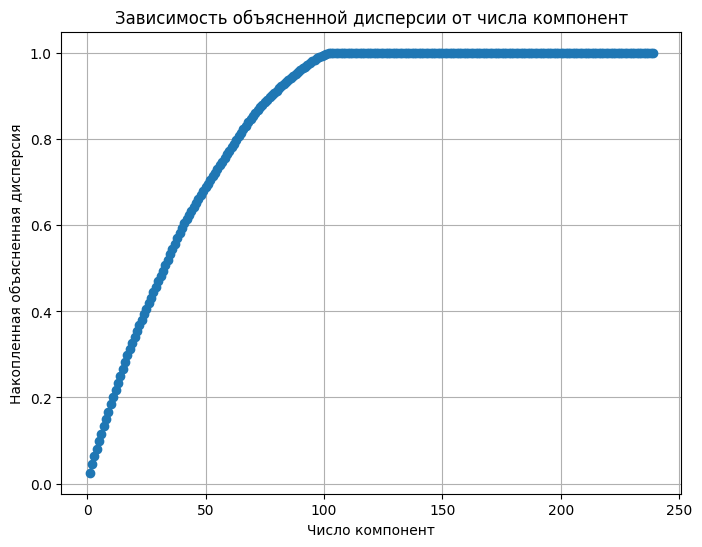

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# Применим PCA без указания числа компонент, чтобы увидеть объясненную дисперсию для всех компонент
pca = PCA()
pca.fit(scaled_data)

# Визуализация доли объясненной дисперсии в зависимости от числа компонент
plt.figure(figsize=(8,6))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Зависимость объясненной дисперсии от числа компонент')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная объясненная дисперсия')
plt.grid(True)
plt.show()

In [15]:
optimal_components = 100


pca = PCA(n_components=optimal_components)
reduced_data = pca.fit_transform(scaled_data)

df_reduced = pd.DataFrame(reduced_data, columns=[f'PC{i+1}' for i in range(optimal_components)])

df_reduced.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC91,PC92,PC93,PC94,PC95,PC96,PC97,PC98,PC99,PC100
0,0.751515,-3.695306,0.323737,-0.947350,-5.985246,-2.823929,-4.909997,-3.788480,3.529911,2.066266,...,-0.068725,0.002023,-0.269072,0.048867,-0.096501,0.163053,-0.331730,0.032383,-0.910941,-1.057136
1,-4.135682,-3.932178,-0.589748,-0.942165,-5.886165,-2.937556,-4.795036,-4.100655,3.886195,1.762593,...,-0.098497,-0.575659,0.314259,0.908963,0.781653,-1.421939,4.198712,0.139187,-0.073304,0.314066
2,-4.423261,-1.308555,0.764857,-1.004285,-3.355042,0.636882,8.051567,7.240219,0.755903,3.235400,...,-0.710159,-0.462109,-0.023882,0.352151,0.390769,-0.025221,0.170863,-0.074863,0.001197,-0.270164
3,-3.942758,-0.743613,0.745188,-0.751811,-2.843214,0.838215,8.226442,7.177652,0.893993,3.350418,...,-0.622925,0.091902,0.388804,-0.123380,0.179509,0.175995,0.955906,-0.124351,0.037355,0.039426
4,1.406357,-2.865034,-0.256684,-1.526266,-3.242829,0.754190,2.597775,5.382785,-8.778723,12.067440,...,0.801727,-1.251422,-1.143640,-0.766458,0.713856,-0.459570,0.356258,-0.052764,-0.015664,-0.658495


In [16]:

X_train, X_test, y_train, y_test = train_test_split(encoded_df, y_bin, test_size=0.2, random_state=42)


svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)


y_pred = svm_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели SVM: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred))

Точность модели SVM: 86.85%
              precision    recall  f1-score   support

         0.0       0.87      1.00      0.93      1724
         1.0       0.00      0.00      0.00       261

    accuracy                           0.87      1985
   macro avg       0.43      0.50      0.46      1985
weighted avg       0.75      0.87      0.81      1985



/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Сбалансируем текст для лучшей интерпретации результатов 

In [34]:
import numpy as np
import random
import pandas as pd

# Получаем индексы каждого класса
class_0_indices = np.where(y_bin == 0)[0]
class_1_indices = np.where(y_bin == 1)[0]

# Преобразуем индексы в списки и перемешиваем их
indices_0 = list(class_0_indices)
random.shuffle(indices_0)

indices_1 = list(class_1_indices)
random.shuffle(indices_1)

min_class = min(len(indices_0), len(indices_1))

# Определяем размеры выборок
test_size = int(min_class * 0.2 // 2)  # Размер тестовой выборки для каждого класса

indices_0 = np.array(indices_0, dtype=int)
indices_1 = np.array(indices_1, dtype=int)

# Тестовый набор (балансируем)
X_test = pd.concat([
    df_reduced.iloc[indices_0[:test_size]],
    df_reduced.iloc[indices_1[:test_size]]
])
y_test = np.concatenate([
    y_bin[indices_0[:test_size]],
    y_bin[indices_1[:test_size]]
])

# Тренировочный набор — всё, что осталось
train_indices = np.concatenate([
    indices_0[test_size:],
    indices_1[test_size:]
])

X_train = df_reduced.iloc[train_indices]
y_train = y_bin[train_indices]

# Проверим размеры выборок
print(f"Размер тренировочной выборки: {X_train.shape}, Размер тестовой выборки: {X_test.shape}")


Размер тренировочной выборки: (9659, 100), Размер тестовой выборки: (264, 100)


(array([132.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 132.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

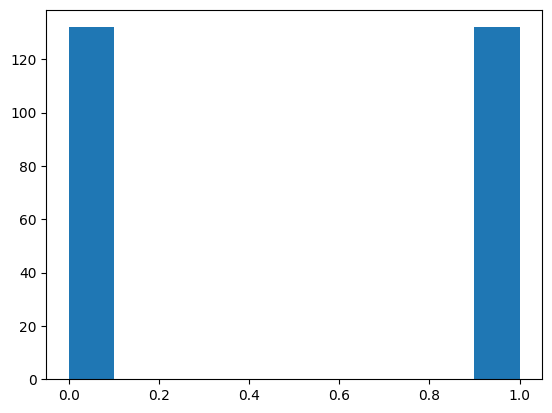

In [35]:
plt.hist(y_test)

### Переделываем модель

In [36]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test.values)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели на сбалансированной тестовой выборке: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred))

Точность модели на сбалансированной тестовой выборке: 50.00%
              precision    recall  f1-score   support

         0.0       0.50      1.00      0.67       132
         1.0       0.00      0.00      0.00       132

    accuracy                           0.50       264
   macro avg       0.25      0.50      0.33       264
weighted avg       0.25      0.50      0.33       264



/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-d

In [32]:
X_test.values

array([[ 2.35708628,  0.63615783, -1.02258831, ..., -0.06547671,
        -0.03597494, -0.29153891],
       [-3.45483944,  0.09706007, -1.63437737, ...,  0.02958609,
         0.0522717 ,  0.07093196],
       [ 1.08261248, -3.72373636,  3.43099471, ..., -0.11448368,
         0.0709875 , -0.35053035],
       ...,
       [ 1.08951003,  2.05280301, -0.85712999, ...,  0.03311256,
         0.11052747, -0.2585791 ],
       [ 1.57762868, -2.67085553,  3.91385846, ...,  0.06827002,
        -0.56481433,  0.35722319],
       [-3.68749145,  1.54590942, -1.29485625, ...,  0.1276715 ,
        -0.10249796,  0.17469545]])

### Random бейзлайн

In [38]:
result = dict()

In [39]:
y_pred_random = np.random.choice([0, 1], size=len(y_test))

accuracy_random = accuracy_score(y_test, y_pred_random)
print(f'Точность рандомного классификатора: {accuracy_random * 100:.2f}%')

print(classification_report(y_test, y_pred_random))
result['random']=y_pred_random

Точность рандомного классификатора: 50.38%
              precision    recall  f1-score   support

         0.0       0.50      0.48      0.49       132
         1.0       0.50      0.52      0.51       132

    accuracy                           0.50       264
   macro avg       0.50      0.50      0.50       264
weighted avg       0.50      0.50      0.50       264



### Как сбалансировать данные?

**Используем параметр class_weight='balanced'**.

Этот параметр автоматически рассчитывает вес для каждого класса в зависимости от его частоты в данных. Это простой и эффективный способ улучшить производительность на меньшем классе без изменения самого набора данных.

In [40]:
svm_model = SVC(kernel='linear', class_weight='balanced')
svm_model.fit(X_train, y_train)


y_pred = svm_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели SVM: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred))
result['balanced_svm']=y_pred

Точность модели SVM: 62.88%
              precision    recall  f1-score   support

         0.0       0.65      0.55      0.60       132
         1.0       0.61      0.71      0.66       132

    accuracy                           0.63       264
   macro avg       0.63      0.63      0.63       264
weighted avg       0.63      0.63      0.63       264



**Oversampling (Увеличение выборки для меньшего класса)**

Этот метод увеличивает количество объектов меньшего класса путем их повторения или создания новых объектов с помощью методов вроде SMOTE (Synthetic Minority Over-sampling Technique). SMOTE генерирует новые синтетические примеры для меньшего класса, создавая между объектами этого класса новые данные на основе ближайших соседей.

In [43]:
!python3 -m pip install imblearn


Defaulting to user installation because normal site-packages is not writeable
  Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)
     |████████████████████████████████| 258 kB 596 kB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [44]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_resampled, y_resampled)

y_pred = svm_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели SVM: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred))

result['balanced_smote']=y_pred

/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Точность модели SVM: 64.77%
              precision    recall  f1-score   support

         0.0       0.66      0.61      0.63       132
         1.0       0.64      0.69      0.66       132

    accuracy                           0.65       264
   macro avg       0.65      0.65      0.65       264
weighted avg       0.65      0.65      0.65       264



**Undersampling (Уменьшение выборки для большего класса)**

In [45]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_resampled, y_resampled)

y_pred = svm_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели SVM: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred))

result['balanced_undersampling']=y_pred

/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Точность модели SVM: 60.23%
              precision    recall  f1-score   support

         0.0       0.62      0.53      0.57       132
         1.0       0.59      0.67      0.63       132

    accuracy                           0.60       264
   macro avg       0.60      0.60      0.60       264
weighted avg       0.60      0.60      0.60       264



**Комбинированные методы (Balanced Ensemble)**

Можно комбинировать oversampling и undersampling, например, сначала уменьшить выборку большего класса, а затем увеличить выборку меньшего. Для этого существуют специальные методы, такие как SMOTEENN и SMOTETomek, которые комбинируют оба подхода.

In [46]:
from imblearn.combine import SMOTEENN

# Применяем SMOTE и ENN для комбинированного увеличения и уменьшения выборки
smote_enn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train)

# Обучаем модель на сбалансированных данных
svm_model = SVC(kernel='linear')
svm_model.fit(X_resampled, y_resampled)

y_pred = svm_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели SVM: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred))

result['balanced_smoteen']=y_pred

/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Точность модели SVM: 52.27%
              precision    recall  f1-score   support

         0.0       0.51      0.86      0.64       132
         1.0       0.57      0.19      0.28       132

    accuracy                           0.52       264
   macro avg       0.54      0.52      0.46       264
weighted avg       0.54      0.52      0.46       264



**Беггинг по разным наборам данных**

In [47]:
# Количество моделей (сколько раз будем делать undersampling и обучать модели)
n_models = 20

# Создаем список для хранения моделей
models = []

# Создаем случайные undersampled подвыборки и обучаем модели на каждой из них
for i in range(n_models):
    # Создаем объект RandomUnderSampler для балансировки классов
    rus = RandomUnderSampler(random_state=i)
    
    # Применяем undersampling к тренировочным данным
    X_resampled, y_resampled = rus.fit_resample(X_train, y_train)
    
    # Обучаем модель SVM на сбалансированной подвыборке
    svm_model = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=i)
    svm_model.fit(X_resampled, y_resampled)
    
    # Добавляем обученную модель в список
    models.append(svm_model)

# Предсказание для каждой модели и объединение результатов (голосование)
y_preds = np.zeros((len(X_test), n_models))

for i, model in enumerate(models):
    y_preds[:, i] = model.predict(X_test)

# Используем "большинство голосов" для финального предсказания
y_pred_final = np.apply_along_axis(lambda x: np.bincount(x.astype(int)).argmax(), axis=1, arr=y_preds)

# Оценка финальных предсказаний
accuracy = accuracy_score(y_test, y_pred_final)
print(f'Точность ансамбля моделей: {accuracy * 100:.2f}%')

# Полный отчет по классификации
print(classification_report(y_test, y_pred_final))
result['balanced_ansambly']=y_pred_final

/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  war

Точность ансамбля моделей: 62.50%
              precision    recall  f1-score   support

         0.0       0.65      0.53      0.59       132
         1.0       0.61      0.72      0.66       132

    accuracy                           0.62       264
   macro avg       0.63      0.62      0.62       264
weighted avg       0.63      0.62      0.62       264



In [49]:
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.svm import SVC

base_svm = SVC(kernel='linear', probability=True)

bbc = BalancedBaggingClassifier(
    estimator=base_svm,      # <-- раньше было base_estimator
    n_estimators=20,
    sampling_strategy='auto',
    random_state=42,
    replacement=False
)

bbc.fit(X_train, y_train)
y_pred = bbc.predict(X_test)


/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:

In [51]:
# Оценка финальных предсказаний
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность cбалансированного беггинга моделей: {accuracy * 100:.2f}%')

# Полный отчет по классификации
print(classification_report(y_test, y_pred))
result['balanced_bagging_ansambly']=y_pred

Точность cбалансированного беггинга моделей: 64.02%
              precision    recall  f1-score   support

         0.0       0.65      0.61      0.63       132
         1.0       0.63      0.67      0.65       132

    accuracy                           0.64       264
   macro avg       0.64      0.64      0.64       264
weighted avg       0.64      0.64      0.64       264



In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Создаем пустой DataFrame для хранения метрик
metrics_df = [] #pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

# Вычисляем метрики для каждой модели
for model_name, y_pred in result.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Добавляем метрики в DataFrame
    metrics_df.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })


metrics_df = pd.DataFrame(metrics_df)

# Устанавливаем столбец 'Model' как индекс
metrics_df = metrics_df.set_index('Model')

# Печатаем таблицу с результатами
print(metrics_df)

                           Accuracy  Precision    Recall  F1-Score
Model                                                             
random                     0.503788   0.503793  0.503788  0.503610
balanced_svm               0.628788   0.632468  0.628788  0.626192
balanced_smote             0.647727   0.648760  0.647727  0.647115
balanced_undersampling     0.602273   0.604437  0.602273  0.600202
balanced_smoteen           0.522727   0.540909  0.522727  0.463068
balanced_ansambly          0.625000   0.629651  0.625000  0.621607
balanced_bagging_ansambly  0.640152   0.640547  0.640152  0.639898


### Попробуем менять ядро

In [64]:
y_train_np = y_train.reshape(-1,1)
x_train_np = X_train.values

y_train_filtered = np.append(y_train_np[y_train_np == 0][:500], y_train_np[y_train_np == 1][:500], 0)
x_train_filteres = np.append(x_train_np[y_train_np[:,0] == 0][:500], x_train_np[y_train_np[:,0] == 1][:500], 0)

In [66]:
from sklearn.model_selection import GridSearchCV

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

param_grid = {
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'C': [0.1, 1, 10],  # Регуляризация
    'gamma': ['scale', 'auto'],  # Важно для rbf и poly
    'degree': [2, 3]  # Важно для poly ядра
}

# Настройка GridSearchCV для перебора параметров
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)
grid.fit(X_resampled, y_resampled)

# Лучшие параметры
print(f'Лучшие параметры: {grid.best_params_}')

/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 1/5] END C=0.1, degree=2, gamma=scale, kernel=linear;, score=0.611 total time=  20.3s
[CV 2/5] END C=0.1, degree=2, gamma=scale, kernel=linear;, score=0.648 total time=  22.7s
[CV 3/5] END C=0.1, degree=2, gamma=scale, kernel=linear;, score=0.657 total time=  22.7s
[CV 4/5] END C=0.1, degree=2, gamma=scale, kernel=linear;, score=0.634 total time=  21.1s
[CV 5/5] END C=0.1, degree=2, gamma=scale, kernel=linear;, score=0.635 total time=  20.4s
[CV 1/5] END C=0.1, degree=2, gamma=scale, kernel=rbf;, score=0.627 total time=  23.9s
[CV 2/5] END C=0.1, degree=2, gamma=scale, kernel=rbf;, score=0.676 total time=  24.2s
[CV 3/5] END C=0.1, degree=2, gamma=scale, kernel=rbf;, score=0.673 total time=  24.5s
[CV 4/5] END C=0.1, degree=2, gamma=scale, kernel=rbf;, score=0.661 total time=  24.8s
[CV 5/5] END C=0.1, degree=2, gamma=scale, kernel=rbf;, score=0.660 total time=  24.4s
[CV 1/5] END C=0.1, degree=2, gamma=scale, kernel=pol

KeyboardInterrupt: 

In [67]:
#END C=0.1, degree=2, gamma=auto, kernel=poly;, score=0.704 total time=  17.0s

In [69]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)

svm_model = SVC(kernel='poly', gamma='auto', C=0.1, degree=2)
svm_model.fit(X_resampled, y_resampled)

y_pred = svm_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели SVM: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred))

result['balanced_undersampling']=y_pred

/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Точность модели SVM: 56.06%
              precision    recall  f1-score   support

         0.0       0.56      0.59      0.57       132
         1.0       0.56      0.53      0.55       132

    accuracy                           0.56       264
   macro avg       0.56      0.56      0.56       264
weighted avg       0.56      0.56      0.56       264



## Секретная техника ниндзя ADD-DEL



### Инициализация
1. **Задаем начальные параметры:**
   - Пусть есть исходные данные `X_train` (признаки) и `y_train` (целевая переменная).
   - Задаем модель (например, SVM) и метрику для оценки (например, accuracy, F1-score).
   - Определяем, будем ли выполнять сжатие размерности (например, через PCA).
   - Инициализируем пустой список выбранных признаков `selected_features = []`.
   - Все доступные признаки помещаем в список `remaining_features`.

### Основной цикл (итерации алгоритма ADD-DEL)
2. **Начинаем основной цикл (ограниченный максимальным количеством итераций):**
   - Пока не достигнуто максимальное количество итераций ИЛИ пока не перестают происходить улучшения.

#### Шаг 1: ADD (Добавление признаков)
3. **Для каждого признака в `remaining_features`:**
   - Добавляем признак к текущему набору выбранных признаков: `current_features = selected_features + [feature]`.
   - Тренируем модель на подмножестве данных с текущими признаками (`X_train[current_features]`).
   - Оцениваем качество модели на валидационном или тестовом наборе (например, `X_test`).
   - **Если добавление признака улучшило метрику** (например, accuracy), добавляем признак в `selected_features` и удаляем его из `remaining_features`.
   - **Если улучшений нет**, оставляем набор признаков без изменений.

#### Шаг 2: DEL (Удаление признаков)
4. **Для каждого признака в `selected_features`:**
   - Удаляем признак из текущего набора: `current_features = selected_features - [feature]`.
   - Повторяем обучение модели и оцениваем её качество.
   - **Если удаление признака не ухудшило метрику**, окончательно удаляем признак из `selected_features`.

### Завершение цикла
5. **Если на шаге ADD или DEL не произошло улучшений**, цикл завершается досрочно.

### Финальный шаг: Оценка
6. **Тренируем модель на финальном наборе признаков:**
   - Оцениваем её качество на тестовой выборке.
   - Возвращаем список выбранных признаков и финальное значение метрики.

---

### Псевдокод:

```python
# Инициализация
selected_features = []
remaining_features = все_признаки
best_score = 0
iteration = 0

# Основной цикл
while iteration < max_iterations:
    улучшено = False
    
    # Шаг 1: ADD (добавляем признаки)
    for признак in remaining_features:
        current_features = selected_features + [признак]
        модель.fit(X_train[current_features], y_train)
        предсказания = модель.predict(X_test[current_features])
        метрика = оценить_метрику(y_test, предсказания)
        
        if метрика > best_score:
            best_score = метрика
            selected_features.append(признак)
            remaining_features.remove(признак)
            улучшено = True
            
    # Шаг 2: DEL (удаляем признаки)
    for признак in selected_features:
        current_features = selected_features - [признак]
        модель.fit(X_train[current_features], y_train)
        предсказания = модель.predict(X_test[current_features])
        метрика = оценить_метрику(y_test, предсказания)
        
        if метрика >= best_score:
            selected_features.remove(признак)
            улучшено = True
    
    # Проверяем, произошло ли улучшение
    if not улучшено:
        break
    
    iteration += 1

# Возвращаем результаты
return selected_features, финальная_метрика


In [75]:


def add_del_feature_selection(X_train, y_train, X_test, y_test, model=SVC(), 
                              metric=accuracy_score, max_iter=10):
    # Инициализация пустого набора признаков
    selected_features = []
    remaining_features = list(range(X_train.shape[1]))  # Все доступные признаки
    best_score = 0  # Лучшая метрика
    
    # Random undersampling
    undersampler = RandomUnderSampler(random_state=42)
    
    # Максимальное количество итераций
    for iteration in range(max_iter):
        improved = False
        
        # Шаг ADD: пробуем добавить каждый из оставшихся признаков
        for feature in remaining_features[:]:
            current_features = selected_features + [feature]
            
            # Undersampling тренировочных данных
            X_resampled, y_resampled = undersampler.fit_resample(X_train[:, current_features], y_train)
            
            # Тренировка модели
            model.fit(X_resampled, y_resampled)
            y_pred = model.predict(X_test[:, current_features])
            score = metric(y_test, y_pred)
            
            if score > best_score:
                best_score = score
                selected_features.append(feature)
                remaining_features.remove(feature)
                improved = True
                print(f"Добавлен признак {feature}, метрика улучшена до {best_score:.4f}")
        
        # Шаг DEL: пробуем удалить каждый из выбранных признаков
        for feature in selected_features[:]:
            current_features = selected_features.copy()
            current_features.remove(feature)
            
            # Undersampling тренировочных данных
            X_resampled, y_resampled = undersampler.fit_resample(X_train[:, current_features], y_train)
            
            # Тренировка модели
            model.fit(X_resampled, y_resampled)
            y_pred = model.predict(X_test[:, current_features])
            score = metric(y_test, y_pred)
            
            if score >= best_score:
                selected_features.remove(feature)
                best_score = score
                improved = True
                print(f"Удален признак {feature}, метрика осталась {best_score:.4f}")
        
        # Если не произошло улучшений в ходе текущей итерации, выходим
        if not improved:
            break

   
    # Обучение модели на отобранных признаках без сжатия размерности
    X_resampled, y_resampled = undersampler.fit_resample(X_train[:, selected_features], y_train)
    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test[:, selected_features])
    final_score = metric(y_test, y_pred)
    print(f"Финальная метрика без сжатия размерности: {final_score:.4f}")
    
    return selected_features, final_score

In [77]:
selected_features, final_score = add_del_feature_selection(X_train.values, y_train, X_test.values, y_test, max_iter=20)
print(f"Выбранные признаки: {selected_features}, Финальная метрика: {final_score:.4f}")

/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Добавлен признак 0, метрика улучшена до 0.5303


/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:

Добавлен признак 5, метрика улучшена до 0.5417


/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:

...

Добавлен признак 62, метрика улучшена до 0.6629


/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:

Добавлен признак 3, метрика улучшена до 0.6667


/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/zoya/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:

Финальная метрика без сжатия размерности: 0.6667
Выбранные признаки: [0, 5, 8, 12, 16, 23, 40, 56, 60, 62, 3], Финальная метрика: 0.6667


In [84]:
X.columns[selected_features]

Index(['Группа_Велик ГЕО', 'Группа_Велосипед Novatrack',
       'Группа_Велосипед Ангарск', 'Группа_Велосипед Девочке',
       'Группа_Велосипед Иркутск', 'Группа_Велосипед Складной',
       '№ Объявления_M-9591380714', '№ Объявления_M-9591380754',
       '№ Объявления_M-9591380762', '№ Объявления_M-9591380772',
       'Группа_Велосипед +для лет/года'],
      dtype='object')